# More Volatile Than Ever? — a quantitative teardown 🔬
### Trend tests under persistence · extreme-day counts · points vs percent · a forecast race

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![More volatile than ever?: Busted](https://img.shields.io/badge/More_volatile_than_ever%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Annual log
realised volatility is tested for a trend three ways — Newey-West, Kiefer-Vogelsang-Bunzel
fixed-b, residual block bootstrap — on a century of monthly total returns and two daily S&P 500
tapes; extreme days are counted against fixed and trailing σ with exact Poisson intervals and a
block-permutation trend test; and the claim, turned into a forecasting rule, races the
long-run and recent alternatives out of sample.

> ⚠️ **Not investment advice.** Real numbers come from frozen bundled tapes (fingerprints
> `5bf075a78851` / `6801b52cecb2` / `317bd3262050`, as-of 2021-12-31; see
> [`docs/results.md`](../docs/results.md)). §4.7 is a **synthetic** control and says so.
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from volhistory import data, strategy as st
print("tapes available:", data.have_real(), "| study as-of", data.AS_OF)

tapes available: True | study as-of 2021-12-31


In [2]:
m = data.load_monthly()      # Fama-French monthly, TOTAL return, 1926-07 -> 2018-11
d = data.load_daily()        # S&P 500 daily, PRICE index, 1990 -> 2021 (partial 2022 dropped)
o = data.load_ohlc()         # S&P 500 daily OHLC, PRICE index, 1999 -> 2018
for p in data.provenance():
    print(f"{p['tape']:8s} {p['label']:55s} {p['first']} -> {p['last']}  fp {p['fingerprint']}")
rv_c = st.annual_rv_from_monthly(m, data.FIRST_FULL_YEAR_MONTHLY, data.LAST_FULL_YEAR_MONTHLY)
rv_d = st.annual_rv_from_daily(d)
rv_p = st.annual_rv_parkinson(o)

monthly  Fama-French Mkt-RF + RF, monthly, TOTAL return          1926-07-31 -> 2018-11-30  fp 5bf075a78851
daily    S&P 500 index level, daily, PRICE index (no dividends)  1990-01-02 -> 2021-12-31  fp 6801b52cecb2
ohlc     S&P 500 Open/High/Low/Close, daily, PRICE index         1999-01-04 -> 2018-12-31  fp 317bd3262050


## 0 · Verdict (real tape), up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | None | Over 91 complete years (1927-2017, Fama-French total return), the trend in log realised volatility is **-5.6% per decade** — the point slope is actually *negative* (Newey-West *t* = -2.13; KVB fixed-b *t* = -2.85, p = 0.26; block-bootstrap p = 0.02), and what slope there is comes from the 1930s sitting at the start. On the daily S&P 500 price index (1990-2021) it is +6.5% per decade (NW *t* = +0.70, KVB p = 0.61); the independent intraday-range estimator (1999-2018) gives -26.2% (NW *t* = -3.06) over a window that opens in the dot-com bust. Extreme days against a fixed long-run σ: 129 sessions beyond 3σ, a fitted trend of +40% per decade that does not survive a test respecting crisis clustering (HAC z = +1.49, block-permutation p = 0.58) — the count is two bursts, 2008-09 and 2020, not a slope. None of the start years from 1927 to 1998 gives a significant rise to 2017. Volatility arrives in storms and then calms down; it does not climb. |
| **Tradability** | Fragile | Framed as a risk manager's choice of next-period volatility, scored out of sample by QLIKE. Century tape (annual, 71 years): LONG-RUN 0.466, RECENT 0.372, TREND 0.329, and a plain 20-year mean with no slope 0.345. Daily tape (monthly, 324 months): LONG-RUN 0.684, RECENT 0.532, TREND 0.839, WINDOW 0.762. The trend-extrapolation rule — the claim turned into a forecast — beats the long-run average on the century (DM *t* = -1.51, not significant) and loses to it monthly (DM *t* = +0.81); against the same window *without* the slope it scores DM *t* = -0.24 (annual) and +0.54 (monthly). Where TREND wins it is because a shorter memory forgets the 1930s, not because volatility rises. The robust lesson is the opposite of the claim's: the best forecasts here mix recent and long-run (BLEND vs LONG-RUN DM *t* = -4.39 annual, -2.30 monthly) — volatility clusters and then mean-reverts. Nothing is traded, so no costs are charged; the stamp grades the trend rule by the pre-registered bar — Fragile rather than Mirage only because that bar asks TREND to beat the long-run average on one tape on a point estimate, which it does by forgetting, not by extrapolating. |
| **More volatile than ever?** | Busted | The 1930s were 2.2× as volatile as 2008-2017 (p = 0.0003). |

> 💡 **In plain words.** Volatility comes in storms that end. Nothing in a century of
> data says the storms are getting stronger; the headlines measure them in points.

## 1 · The claim, and the hypotheses that would make it true

- **H₁ (trend).** Log realised volatility of the US market has a positive linear trend,
  1927-2017, robust to persistence.
- **H₂ (recent tape).** The same holds on daily S&P 500 data, 1990-2021, and on an independent
  range-based estimator, 1999-2018.
- **H₃ (tails).** The yearly rate of |r| > 3σ days trends up (fixed σ), robust to crisis
  clustering.
- **H₄ (perception).** Point moves trend up even under constant percent volatility — the
  mechanism that would make H₁-H₃ *feel* true when false.
- **H₅ (forecast).** Extrapolating the trend beats the long-run average as a risk forecast.

## 2 · So what?

Under H₁ every historical risk number is biased low by a growing amount and VaR models should
be trend-adjusted. Under its negation the right prior is a stationary, persistent volatility —
which is what every GARCH and HAR model already assumes — and trend-adjusting adds error.

## 3 · How we'd know — the tests and the pre-registered bar

A persistent stationary series wanders, and an OLS trend through it over-rejects badly. The
Newey-West correction with a rule-of-thumb bandwidth helps but still over-rejects at volatility's
persistence. The fixed-b approach (Kiefer, Vogelsang & Bunzel 2000; Kiefer & Vogelsang 2002)
sets the Bartlett bandwidth to the whole sample; the statistic's null distribution is then
non-normal but pivotal, and its critical values are simulated below rather than borrowed.

In [3]:
null = st.kvb_null_distribution()
print(f"KVB fixed-b |t| for a trend slope: 90% {np.quantile(null, .90):.2f}, "
      f"95% {np.quantile(null, .95):.2f}, 99% {np.quantile(null, .99):.2f}  (normal: 1.64 / 1.96 / 2.58)")
print()
print(st.verdict.__doc__)

KVB fixed-b |t| for a trend slope: 90% 4.64, 95% 5.91, 99% 8.95  (normal: 1.64 / 1.96 / 2.58)

Stamps by a pre-registered rule.

Signal — the claim is that volatility (and the frequency of extreme days) is rising.

- ``pass_century``: the 1927-2017 annual log-RV trend passes :func:`passes` (slope > 0, NW
  t ≥ 2, KVB fixed-b p < 0.05).
- ``pass_daily``: the same bar on 1990-2021 daily-based annual log RV.
- ``pass_extremes``: the yearly count of fixed-σ 3σ days trends up with HAC z ≥ 2 **and**
  block-permutation p < 0.05.

**Real** if ``pass_century`` and (``pass_daily`` or ``pass_extremes``). **Mixed** if exactly
one of ``pass_century`` / ``pass_daily`` holds (a genuine split by tape). **Weak** if neither
passes but the extreme-day trend does, or either point slope is positive with NW t ≥ 1.
**None** otherwise.

Tradability — the claim turned into a risk rule ("extrapolate the rise").

**Investable** if TREND beats both LONG-RUN and RECENT with DM p < 0.05 on both tapes.
**Fragile** 

> 💡 **In plain words.** Because volatility is sticky, a *t* of 3 on a volatility trend
> is much weaker evidence than a *t* of 3 on, say, an average return. The fixed-b test charges
> for that stickiness honestly; its 5% hurdle is about 5.91, not 1.96.

## 4 · The teardown

### 4.1 · Trend tests on three tapes and two estimators

In [4]:
rows = {}
rows["century, monthly TR (1927-2017)"] = st.trend_test(np.log(rv_c))
rows["S&P daily close-to-close (1990-2021)"] = st.trend_test(np.log(rv_d))
rows["S&P daily close-to-close, arch (1999-2018)"] = st.trend_test(np.log(st.annual_rv_from_daily(o["close"])))
rows["S&P Parkinson range (1999-2018)"] = st.trend_test(np.log(rv_p))
tt = pd.DataFrame(rows).T[["n", "pct_per_decade", "t_ols", "t_nw", "nw_lags", "t_kvb", "p_kvb", "p_boot", "rho1"]]
print(tt.astype(float).round(3).to_string())
print("\npasses the pre-registered UP bar:", {k: st.passes(v) for k, v in rows.items()})

                                                 n  pct_per_decade   t_ols    t_nw  nw_lags   t_kvb  p_kvb  p_boot   rho1
century, monthly TR (1927-2017)            91.0000         -0.0560 -3.4790 -2.1260   3.0000 -2.8480 0.2590  0.0240 0.5190
S&P daily close-to-close (1990-2021)       32.0000          0.0650  0.7700  0.7030   3.0000  1.1780 0.6120  0.5540 0.4020
S&P daily close-to-close, arch (1999-2018) 20.0000         -0.2270 -1.6310 -2.5120   2.0000 -4.6330 0.1010  0.1540 0.3560
S&P Parkinson range (1999-2018)            20.0000         -0.2620 -2.0180 -3.0620   2.0000 -5.9230 0.0490  0.0760 0.3290

passes the pre-registered UP bar: {'century, monthly TR (1927-2017)': False, 'S&P daily close-to-close (1990-2021)': False, 'S&P daily close-to-close, arch (1999-2018)': False, 'S&P Parkinson range (1999-2018)': False}


The century slope is negative: NW *t* = -2.13, bootstrap p ≈ 0.02 — but the fixed-b
p is 0.26. The decline is the 1930s at the start of the window; the honest test
will not certify it either way. The daily tape slopes up at +6.5% per decade with
NW *t* = +0.70 — nothing. The 1999-2018 window slopes *down* on both estimators, a
start-date effect (it opens in the dot-com bust).

> 💡 **In plain words.** Pick the window and you pick the answer. That is the signature
> of a series without a trend.

### 4.2 · Start-year sensitivity

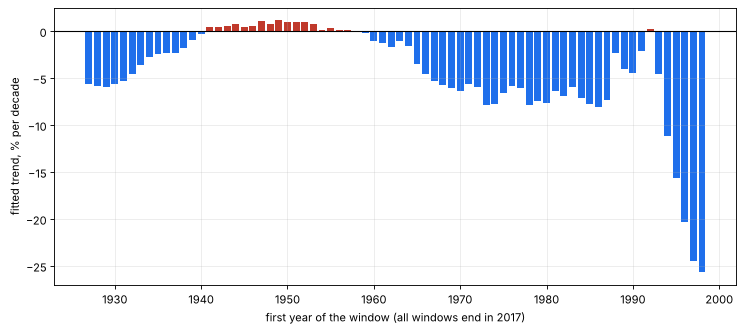

slope > 0 from 25% of start years; significantly up (full bar) from 0%


In [5]:
starts = st.trend_from_every_start(np.log(rv_c), min_len=20)
fig, ax = plt.subplots(figsize=(11, 4.5))
c = np.where(starts["slope"] > 0, "#c0392b", "#1f6feb")
ax.bar(starts.index, starts["pct_per_decade"] * 100, color=c)
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("first year of the window (all windows end in 2017)")
ax.set_ylabel("fitted trend, % per decade")
plt.show()
up = (starts["slope"] > 0) & (starts["t_nw"] >= 2) & (starts["p_kvb"] < 0.05)
print(f"slope > 0 from {np.mean(starts['slope'] > 0):.0%} of start years; "
      f"significantly up (full bar) from {up.mean():.0%}")

### 4.3 · Four eras

           months    vol  ci_lo  ci_hi  worst_month  within_slope_pct_decade  within_t_nw
era                                                                                      
1926-1945     234 0.2832 0.2101 0.3511      -0.2910                  -0.3273      -1.6104
1946-1969     288 0.1286 0.1165 0.1403      -0.1014                  -0.0633      -0.8132
1970-1989     240 0.1721 0.1470 0.1990      -0.2264                  -0.0137      -0.1261
1990-2018     347 0.1491 0.1291 0.1710      -0.1715                  -0.0448      -0.4163


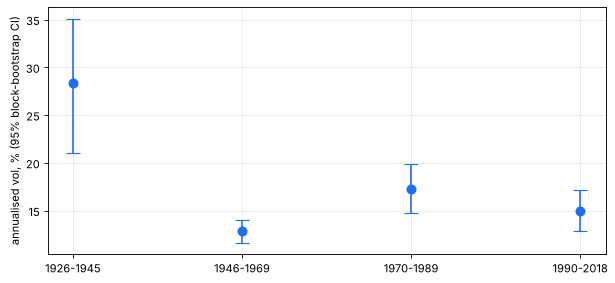

In [6]:
era = st.era_table(m, data.ERAS)
print(era.round(4).to_string())
fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(range(len(era)), era["vol"] * 100,
            yerr=[(era["vol"] - era["ci_lo"]) * 100, (era["ci_hi"] - era["vol"]) * 100],
            fmt="o", capsize=6, color="#1f6feb", ms=8)
ax.set_xticks(range(len(era))); ax.set_xticklabels(era.index)
ax.set_ylabel("annualised vol, % (95% block-bootstrap CI)")
plt.show()

> 💡 **In plain words.** The modern era (1990-2018) sits between the calm post-war decades
> and the turbulent 1970s-80s, and far below the Depression era. No within-era trend is
> significant either.

### 4.4 · Extreme days: fixed σ vs trailing σ

rates per 1,000 sessions
                    total  1990-99  2000-09  2010-19  2020-21  trend/decade  HAC z  block-perm p
rule                                                                                            
|r| > 3σ, fixed       129   4.7000  31.4000   6.8000  41.6000        0.4040 1.4900        0.5670
|r| > 3σ, trailing    125  11.9000  16.3000  15.1000  37.6000        0.3740 2.0470        0.5360
|r| > 4σ, fixed        54   1.6000  13.5000   1.6000  23.8000        0.6220 1.8510        0.5200
|r| > 4σ, trailing     42   3.1000   4.0000   5.6000  21.8000        0.8700 2.6310        0.6920


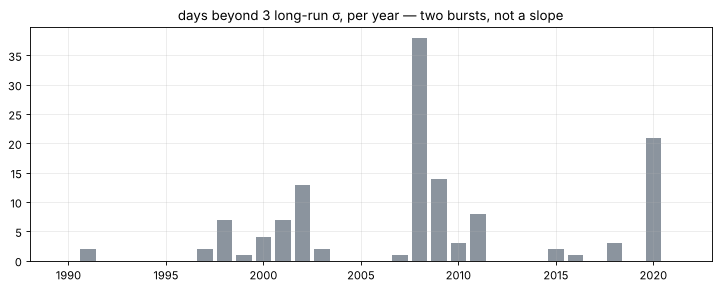

months beyond 3σ on the century tape, by decade: {'1920s': 1, '1930s': 11, '1940s': 1, '1950s': 0, '1960s': 0, '1970s': 0, '1980s': 1, '1990s': 1, '2000s': 1, '2010s': 0}


In [7]:
lr = st.log_returns_from_price(d)
B = (("1990-99", 1990, 1999), ("2000-09", 2000, 2009), ("2010-19", 2010, 2019), ("2020-21", 2020, 2021))
out = []
for k in (3, 4):
    for mode in ("fixed", "trailing"):
        f = st.extreme_days(lr, k, mode)
        tab = st.count_table(f, B)
        ct = st.count_trend(f, n_boot=999)
        out.append({"rule": f"|r| > {k}σ, {mode}", "total": int(ct["total"]),
                    **{b: round(tab.loc[b, "rate"], 1) for b in tab.index},
                    "trend/decade": ct["pct_per_decade"], "HAC z": ct["z_hac"], "block-perm p": ct["p_perm"]})
print("rates per 1,000 sessions")
print(pd.DataFrame(out).set_index("rule").round(3).to_string())
f3 = st.extreme_days(lr, 3.0, "fixed")
yearly = f3.groupby(f3.index.year).sum()
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(yearly.index, yearly.values, color="#8b949e")
ax.set_title("days beyond 3 long-run σ, per year — two bursts, not a slope")
plt.show()
print("months beyond 3σ on the century tape, by decade:", st.monthly_extremes_by_decade(m)["count"].to_dict())

Against a fixed σ the 2000s and 2020-21 dominate; against a trailing σ the rate of *surprising*
days drifts up across decades — calm regimes broken suddenly, which is a statement about the
volatility of volatility, not its level. The HAC *z* on the trailing counts can exceed 2; the
block permutation, which keeps each crisis cluster together, puts every version at p > 0.5. On
the century tape, 11 of the 16 three-sigma *months* are in the 1930s.

> 💡 **In plain words.** Counting crash days and fitting a line treats 2008's dozens of
> wild days as dozens of independent pieces of evidence. They are one event.

### 4.5 · Points versus percent: the decomposition

In [8]:
pp = st.points_vs_percent(d)
tab = pd.DataFrame({k: pp[k] for k in ("trend_points", "trend_pct", "trend_level")}).T
print(tab[["pct_per_decade", "slope", "t_nw", "p_kvb"]].astype(float).round(4).to_string())
print(f"\nslope(points) = {pp['trend_points']['slope']:.4f}  vs  slope(level) + slope(percent) = "
      f"{pp['trend_level']['slope'] + pp['trend_pct']['slope']:.4f}")
print("record POINT drops:", [(str(i.date()), round(v)) for i, v in pp["records_points"].items()])
print("record PERCENT drops:", [(str(i.date()), round(v, 3)) for i, v in pp["records_pct"].items()])

# the mechanism, isolated: a constant-volatility index (SYNTHETIC)
g, _ = data.synthetic_returns(n_years=32, freq="D", signal_strength=0.0, logvol_sd=1e-9, drift=0.08, seed=7)
pg = st.points_vs_percent(g["price"], big_points=10.0)
print(f"\nSYNTHETIC constant-σ index: points {pg['trend_points']['pct_per_decade']:+.0%}/decade "
      f"(NW t {pg['trend_points']['t_nw']:+.1f}), percent {pg['trend_pct']['pct_per_decade']:+.1%}/decade")

              pct_per_decade  slope   t_nw  p_kvb
trend_points          0.9460 0.0666 4.9230 0.0160
trend_pct             0.0365 0.0036 0.3932 0.7822
trend_level           0.8899 0.0637 9.8678 0.0000

slope(points) = 0.0666  vs  slope(level) + slope(percent) = 0.0672
record POINT drops: [('1996-03-08', -20), ('1997-04-11', -21), ('1997-08-15', -24), ('1997-10-27', -65), ('1998-08-31', -70), ('2000-04-14', -84), ('2008-09-29', -107), ('2018-02-05', -113), ('2020-02-27', -138), ('2020-03-09', -226), ('2020-03-12', -261), ('2020-03-16', -325)]
record PERCENT drops: [('1997-10-27', -0.069), ('2008-09-29', -0.088), ('2008-10-15', -0.09), ('2020-03-12', -0.095), ('2020-03-16', -0.12)]



SYNTHETIC constant-σ index: points +126%/decade (NW t +17.7), percent -0.8%/decade


> 💡 **In plain words.** Twelve "biggest point drop ever" days in 1995-2021, against five
> in percent — and four of the twelve came in three weeks of 2020. A market that grows ~7% a
> year makes its point moves grow ~7% a year with *no change in risk*. The synthetic index,
> volatility held exactly constant, reproduces the headline trend on its own.

### 4.6 · Recency: the remembered decade against the 1930s

In [9]:
dc = st.decade_contrast(m, (1930, 1939), (2008, 2017))
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in dc.items()})

{'a': (1930, 1939), 'b': (2008, 2017), 'vol_a': 0.3533, 'vol_b': 0.1578, 'ratio': 2.2389, 'diff': 0.1955, 'ci_lo': 0.0853, 'ci_hi': 0.2938, 'p': 0.0003, 'worst_month_a': -0.291, 'worst_month_b': -0.1715, 'n_down10_a': 15, 'n_down10_b': 2}


The decade with the global financial crisis was **15.8%** annualised against
**35.3%** for the 1930s (block-bootstrap p = 0.0003 on the difference). The
availability heuristic (Tversky & Kahneman 1973) does the rest: the reference class is "what I
remember", not "what happened".

### 4.7 · Synthetic control — can the bar see a trend that is there? (SYNTHETIC)

A machinery proof, never market evidence. Ninety-year monthly stochastic-volatility worlds with
persistent log volatility; ``signal_strength`` scales a planted trend that, at 1.0, triples
volatility across the sample.

                 fire_rate  nw_rate  ols_rate  mean_slope  true_slope
signal_strength                                                      
0.0000              0.0667   0.0667    0.0667     -0.0005      0.0000
0.2500              0.1333   0.3333    0.4000      0.0025      0.0031
0.5000              0.5333   0.7333    0.8000      0.0055      0.0061
0.7500              0.6667   0.9333    0.9333      0.0086      0.0092
1.0000              0.9333   0.9333    1.0000      0.0117      0.0122


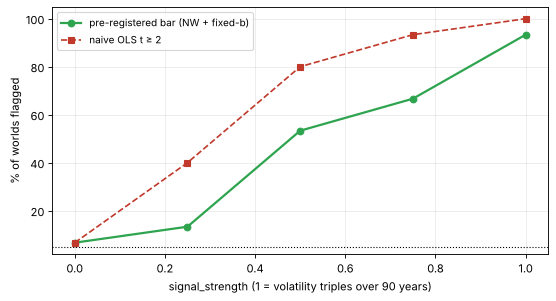

In [10]:
rows = [st.synthetic_detection(s, seeds=range(15)) for s in (0.0, 0.25, 0.5, 0.75, 1.0)]
pw = pd.DataFrame(rows).set_index("signal_strength")
print(pw[["fire_rate", "nw_rate", "ols_rate", "mean_slope", "true_slope"]].round(4).to_string())
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pw.index, pw["fire_rate"] * 100, "o-", color="#2ea44f", lw=2, label="pre-registered bar (NW + fixed-b)")
ax.plot(pw.index, pw["ols_rate"] * 100, "s--", color="#c0392b", lw=1.5, label="naive OLS t ≥ 2")
ax.axhline(5, color="k", ls=":", lw=1)
ax.set_xlabel("signal_strength (1 = volatility triples over 90 years)"); ax.set_ylabel("% of worlds flagged")
ax.legend(fontsize=9); plt.show()

> 💡 **In plain words.** The detector catches a planted rise in most worlds
> (80% at full strength in the 40-world run in `results.md`) and almost never
> invents one (2% on the null). A real rise of the size the claim implies would
> have been seen.

## 5 · The verdict, recomputed live from the tapes

In [11]:
import importlib.util
spec = importlib.util.spec_from_file_location("verify", os.path.abspath("../examples/verify.py"))
verify = importlib.util.module_from_spec(spec); spec.loader.exec_module(verify)
with contextlib.redirect_stdout(io.StringIO()):
    h = verify.report()
v = h["_verdict"]
print(f"Signal: {v['signal']}   Tradability: {v['trad']}   More volatile than ever? {v['myth']}")
print("flags:", v["flags"])
print()
print(v["one_sentence"])

Signal: None   Tradability: Fragile   More volatile than ever? Busted
flags: {'pass_century': False, 'pass_daily': False, 'pass_extremes': False}

A century of US market volatility shows no upward trend (-5.6% per decade, KVB p = 0.26), the 1930s were 2.2× as volatile as 2008-2017, and the record crashes in the headlines are point moves that grow with the index (+95% per decade in points vs +4% in percent) — a risk manager should mix recent and long-run volatility, not extrapolate a rise.


**Signal: None.** Over 91 complete years (1927-2017, Fama-French total return), the trend in log realised volatility is **-5.6% per decade** — the point slope is actually *negative* (Newey-West *t* = -2.13; KVB fixed-b *t* = -2.85, p = 0.26; block-bootstrap p = 0.02), and what slope there is comes from the 1930s sitting at the start. On the daily S&P 500 price index (1990-2021) it is +6.5% per decade (NW *t* = +0.70, KVB p = 0.61); the independent intraday-range estimator (1999-2018) gives -26.2% (NW *t* = -3.06) over a window that opens in the dot-com bust. Extreme days against a fixed long-run σ: 129 sessions beyond 3σ, a fitted trend of +40% per decade that does not survive a test respecting crisis clustering (HAC z = +1.49, block-permutation p = 0.58) — the count is two bursts, 2008-09 and 2020, not a slope. None of the start years from 1927 to 1998 gives a significant rise to 2017. Volatility arrives in storms and then calms down; it does not climb.

**Tradability: Fragile.** Framed as a risk manager's choice of next-period volatility, scored out of sample by QLIKE. Century tape (annual, 71 years): LONG-RUN 0.466, RECENT 0.372, TREND 0.329, and a plain 20-year mean with no slope 0.345. Daily tape (monthly, 324 months): LONG-RUN 0.684, RECENT 0.532, TREND 0.839, WINDOW 0.762. The trend-extrapolation rule — the claim turned into a forecast — beats the long-run average on the century (DM *t* = -1.51, not significant) and loses to it monthly (DM *t* = +0.81); against the same window *without* the slope it scores DM *t* = -0.24 (annual) and +0.54 (monthly). Where TREND wins it is because a shorter memory forgets the 1930s, not because volatility rises. The robust lesson is the opposite of the claim's: the best forecasts here mix recent and long-run (BLEND vs LONG-RUN DM *t* = -4.39 annual, -2.30 monthly) — volatility clusters and then mean-reverts. Nothing is traded, so no costs are charged; the stamp grades the trend rule by the pre-registered bar — Fragile rather than Mirage only because that bar asks TREND to beat the long-run average on one tape on a point estimate, which it does by forgetting, not by extrapolating.

## 6 · Could you trade it? The risk manager's race in detail

One period of lag: each forecast uses data to the end of period *t* and is scored on *t+1*.
QLIKE on variances; Diebold-Mariano with Newey-West (3 lags) on the loss differential.

ANNUAL (century) 71 forecasts
LONG-RUN   0.4660
RECENT     0.3720
TREND      0.3290
BLEND      0.3180
WINDOW     0.3450
                    mean_diff       t      p
TREND_vs_LONG-RUN     -0.1370 -1.5130 0.1300
TREND_vs_RECENT       -0.0430 -0.7480 0.4540
TREND_vs_WINDOW       -0.0160 -0.2440 0.8070
RECENT_vs_LONG-RUN    -0.0940 -1.0160 0.3090
BLEND_vs_LONG-RUN     -0.1490 -4.3940 0.0000

MONTHLY (daily tape) 324 forecasts
LONG-RUN   0.6840
RECENT     0.5320
TREND      0.8390
BLEND      0.5060
WINDOW     0.7620
                    mean_diff       t      p
TREND_vs_LONG-RUN      0.1550  0.8110 0.4180
TREND_vs_RECENT        0.3070  2.1660 0.0300
TREND_vs_WINDOW        0.0770  0.5370 0.5910
RECENT_vs_LONG-RUN    -0.1520 -1.2590 0.2080
BLEND_vs_LONG-RUN     -0.1780 -2.3020 0.0210



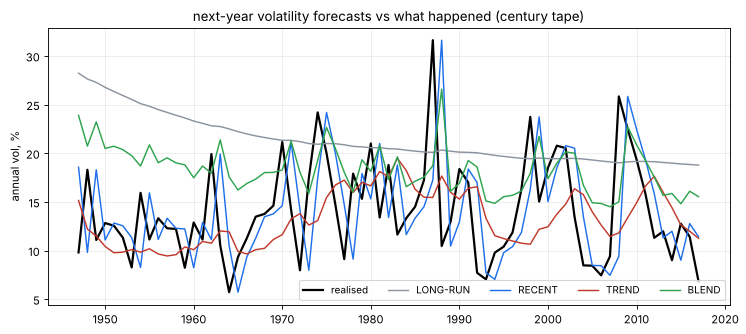

In [12]:
fa = st.forecast_race(rv_c ** 2, recent=1, trend_window=20, burn=20)
fm = st.forecast_race(st.monthly_rv_from_daily(d), recent=12, trend_window=60, burn=60)
for name, f in (("ANNUAL (century)", fa), ("MONTHLY (daily tape)", fm)):
    print(name, f["n"], "forecasts")
    print(pd.Series(f["mean_qlike"]).round(3).to_string())
    print(pd.DataFrame(f["dm"]).T[["mean_diff", "t", "p"]].astype(float).round(3).to_string())
    print()
F = fa["forecasts"]
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(F.index, np.sqrt(F["realised"]) * 100, "k-", lw=2, label="realised")
for k, c in (("LONG-RUN", "#8b949e"), ("RECENT", "#1f6feb"), ("TREND", "#c0392b"), ("BLEND", "#2ea44f")):
    ax.plot(F.index, np.sqrt(F[k]) * 100, color=c, lw=1.3, label=k)
ax.set_ylabel("annual vol, %"); ax.legend(fontsize=9, ncol=5)
ax.set_title("next-year volatility forecasts vs what happened (century tape)")
plt.show()

> 💡 **In plain words.** The long-run average spends decades too high because it still
> remembers 1932; recent history over-reacts to every storm; the extrapolated trend does both.
> Half long-run, half recent wins both races (DM *t* ≈ −4.4 annual, −2.3 monthly against the
> long-run). Nothing is traded and no costs apply — the stamp grades the trend rule, which
> clears the pre-registered *Fragile* bar only on a non-significant point estimate that
> vanishes against a slope-free window.

## 7 · Going further

- **Idiosyncratic volatility.** Campbell, Lettau, Malkiel & Xu (2001) — rising firm-level, flat
  market-level volatility through the 1990s. A stock-panel fork could re-test it after 2000.
- **Long memory.** Volatility's autocorrelations decay hyperbolically; a fractionally
  integrated null (rather than AR(1)) would make the trend tests even more conservative. A
  fork could run Vogelsang's (1998) t-PS or a sieve bootstrap.
- **Volatility of volatility.** The trailing-σ counts hint that calm regimes break more
  abruptly; a test on the dispersion of log RV, not its level, is the natural next study.
- **Intraday.** Flash-crash-style events are invisible at daily frequency; the HFT version of
  the claim needs tick data.